In [1]:
import numpy as np, pickle, sys, matplotlib as mpl, pickle, os
import matplotlib.pyplot as plt, matplotlib.colors as colors
from matplotlib import ticker, cm

FUKA_path = os.getenv('HOME')+'/lib/fuka'
pyFUKA_path = FUKA_path+'/codes/PythonTools'
pyFUKA_libspath = pyFUKA_path+'/lib/'
sys.path.append(pyFUKA_libspath)
os.environ["HOME_KADATH)"] = FUKA_path
%env HOME_KADATH=$FUKA_path

env: HOME_KADATH=/home/tootle/lib/fuka


In [2]:
from fuka_plot_tools.setup_utils import get_reader

In [50]:
data_base_path="/home/tootle/lib/falcon_data"
# initial_data_path=pyFUKA_path+'/Example_id/converged_NS_TOTAL_BC.togashi.2.23.-0.4.0.11.dat'
# initial_data_path=FUKA_path+'/codes/reader_test/NS_ISO_UNIFORM_ROT.APR4.madm.1.35.omega.0.0.11.dat'
initial_data_path=data_base_path+"/NS_ISO_UNIFORM_ROT.gam2.madm.1.4.omega.0.0.09.dat"
initial_data_path=data_base_path+"/NS_ISO_UNIFORM_ROT.gam2.madm.1.4.chi.0.2.0.09.dat"
if os.path.isfile(initial_data_path) == True:
    readerISO = get_reader(initial_data_path, ns_iso_uniformrot=True)
else:
    print("{} not found",initial_data_path)

In [51]:
initial_data_path=data_base_path+"/NS_TOTAL_BC.gam2.madm.1.4.chi.0.0.09.dat"
initial_data_path=data_base_path+"/NS_TOTAL_BC.gam2.madm.1.4.chi.0.2.0.09.dat"
print(initial_data_path)
if os.path.isfile(initial_data_path) == True:
    readerNS = get_reader(initial_data_path, ns=True)
else:
    print("{} not found",initial_data_path)

/home/tootle/lib/falcon_data/NS_TOTAL_BC.gam2.madm.1.4.chi.0.2.0.09.dat


In [5]:
for v in readerISO.vars:
    if 'Kadath' in type(reader.vars[v]).__name__:
        print("{:10}: {}".format(v, reader.vars[v]))

NameError: name 'reader' is not defined

In [6]:
readerISO.getExporterKeys()

['betax',
 'betay',
 'betaz',
 'eps',
 'gxx',
 'gxy',
 'gxz',
 'gyy',
 'gyz',
 'gzz',
 'kxx',
 'kxy',
 'kxz',
 'kyy',
 'kyz',
 'kzz',
 'lapse',
 'press',
 'rho',
 'velx',
 'vely',
 'velz']

In [83]:
y1, y2 = [-10, 10]
npts = 256

y_coords = np.linspace(y1, y2, num=npts)

x1, x2 = [-10,10]
x_coords = np.linspace(x1, x2, num=npts)

coords_lst = [[x,0,y] for y in y_coords for x in x_coords]

In [84]:
dataISO = readerISO.getExporterFieldValues("gyy", coords_lst)
dataISO = np.array(dataISO)
dataISO = dataISO.reshape(npts,npts)

gyy: 7


In [85]:
dataNS = readerNS.getExporterFieldValues("gyy", coords_lst)
dataNS = np.array(dataNS)
dataNS = dataNS.reshape(npts,npts)

gyy: 7


In [86]:
X, Y = np.meshgrid(x_coords, y_coords)

In [93]:
norm = None #colors.LogNorm(vmin=1e-10, vmax = 1e-2, clip=False) 
# norm = colors.Normalize(vmin=1, vmax = 2, clip=False) 

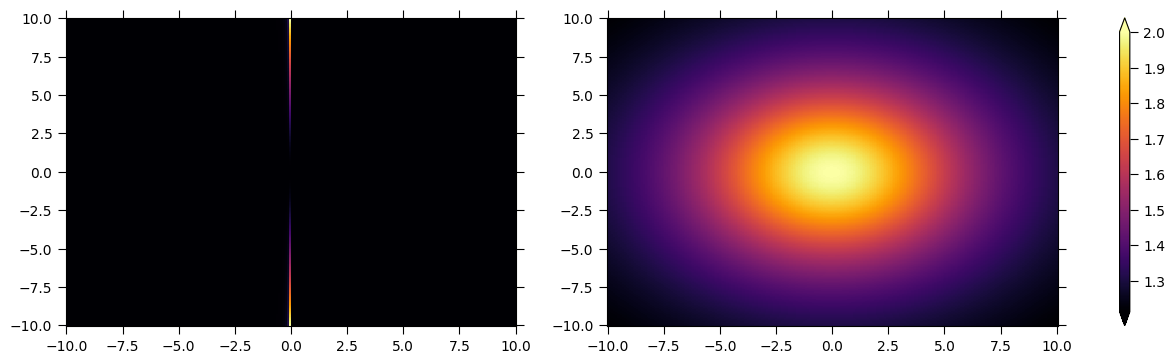

In [94]:
plt.rcParams.update({
'figure.figsize'    : [8.0 * 2, 4],
'image.cmap' : 'inferno'
})
fig,axs = plt.subplots(1,2)
cs=axs[0].pcolor(X, Y, dataISO, norm=norm)
axs[1].pcolor(X, Y, dataNS, norm=norm)
cbarax,kw = mpl.colorbar.make_axes(axs, location='right', orientation='vertical', aspect=30)
cbar = fig.colorbar(
        cs,
        cax=cbarax, ticklocation='right',
        orientation='vertical', extend='both',
        # ticks=np.linspace(norm.vmin, norm.vmax, num=5)
      )

In [ ]:
plt.close('all')
plt.plot(coords_lst, data1,label="exportval")
plt.plot(coords_lst, data2,label="fieldval")
plt.legend()

In [ ]:
# this allows you to use "cd" in cells to change directories instead of requiring "%cd"
%automagic on
# override IPython's default %%bash to not buffer all output
from IPython.core.magic import register_cell_magic
@register_cell_magic
def bash(line, cell): get_ipython().system(cell)

# this (non-default package) keeps the end of shell output in view
try: import scrolldown
except ModuleNotFoundError: pass


In [ ]:
%%bash
# This is stored in $HOME_KADATH/codes/PythonTools/Example_2D.sh
cd $HOME_KADATH/codes/PythonTools
f=${HOME_KADATH}/codes/PythonTools/Example_id/converged_BHNS_ECC_RED.togashi.35.0.6.0.52.3.6.q0.487603.0.1.11.dat
qf=$f
./plot_fukaid_2D.py \
    --bhns \
    -f $f --npts 256 \
    --vars eps --extent -45 45 0 45 \
    --qvar vel --qpts 64 --qscale 0.05 \
    -qf $qf --cmap viridis --qcmap coolwarm \
    --cbar --landscape --log

In [ ]:
def show_img(path_abs):
    img = plt.imread(path_abs)
    plt.close('all')
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_axis_off()
    ax.imshow(img)

In [ ]:
show_img(pyFUKA_path+'/fig-2D.png')

In [ ]:
%%bash
cd $pyFUKA_path
./plot_fukaid_2D.py --help

In [ ]:
%%bash
# The same can be done for 1D
cd $HOME_KADATH/codes/PythonTools
f=${HOME_KADATH}/codes/PythonTools/Example_id/converged_BHNS_ECC_RED.togashi.35.0.6.0.52.3.6.q0.487603.0.1.11.dat
qf=$f
./plot_fukaid_1D.py \
    --bhns \
    -f $f --npts 256 \
    --vars cPsi rho P/rho --extent -45 45 --log

In [ ]:
show_img(pyFUKA_path+'/fig-1D.png')

In [ ]:
%%bash
# The same can be done for 1D
cd $HOME_KADATH/codes/PythonTools
f=${HOME_KADATH}/codes/PythonTools/Example_id/converged_BHNS_ECC_RED.togashi.35.0.6.0.52.3.6.q0.487603.0.1.11.dat
qf=$f
./plot_fukaid_1D.py \
    --bhns \
    -f $f --npts 256 \
    --vars cPsi rho P/rho --extent -27.5 -7.5 --log

In [ ]:
show_img(pyFUKA_path+'/fig-1D.png')